# Credit Card Fraud Detection

## Objective

Detect fraudulent credit card transactions using an Isolation Forest anomaly detection model, on a highly imbalanced dataset where fraud makes up a tiny fraction of all transactions.


## Step 1: Import Libraries


In [89]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 2: Load & Explore Data


In [90]:
df = pd.read_csv("creditcard.csv")

In [91]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [93]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [94]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Step 3: Class Distribution (EDA)


In [95]:
fraud_count = (df['Class'] == 1).sum()
non_fraud_count = (df['Class'] == 0).sum()
fraud_ratio = fraud_count / non_fraud_count

print("Fraudulent transactions:", fraud_count)
print("Non-fraudulent transactions:", non_fraud_count)
print(f"Fraud ratio: {fraud_ratio:.5f}")


Fraudulent transactions: 492
Non-fraudulent transactions: 284315
Fraud ratio: 0.00173


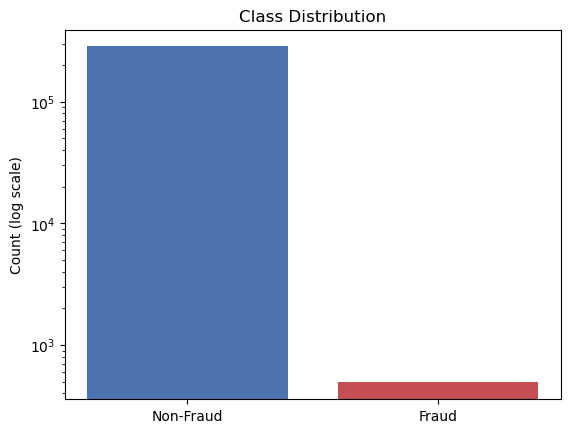

In [96]:
# class balance is extremely skewed, log scale makes both bars visible
plt.bar(['Non-Fraud', 'Fraud'], [non_fraud_count, fraud_count], color=['#4C72B0', '#C44E52'])
plt.yscale('log')
plt.ylabel('Count (log scale)')
plt.title('Class Distribution')
plt.show()


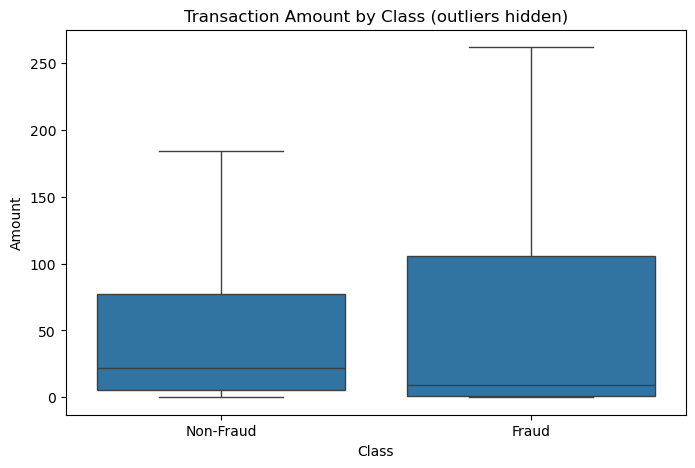

In [97]:
# transaction amount distribution by class
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df, showfliers=False)
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.title('Transaction Amount by Class (outliers hidden)')
plt.show()


## Step 4: Feature Selection


In [98]:
features = [x for x in df.columns if x not in "Class"]
output = df["Class"]

## Step 5: Train/Test Split


In [99]:
X_train,X_test,y_train,y_test = train_test_split(df[features],output,test_size = 0.2)

## Step 6: Model Training - Isolation Forest


In [100]:
# contamination is set to match the real fraud ratio in the data (~0.0017),
# telling the model roughly what fraction of points to treat as anomalies


In [101]:
model = IsolationForest(contamination = 0.0017,random_state = 42)
model.fit(X_train)
predictions = model.predict(X_test)

## Step 7: Convert Predictions to Class Labels


In [102]:
# IsolationForest outputs 1 for inliers and -1 for outliers/anomalies;
# remap those to match our Class labels (0 = non-fraud, 1 = fraud)


In [103]:
predictions[(predictions == 1)] = 0
predictions[(predictions == -1)] = 1

## Step 8: Evaluate the Model


In [104]:
acc = accuracy_score(y_test,predictions)

In [105]:
print(acc)

0.9972437765527896


In [106]:
# accuracy alone is misleading on such an imbalanced dataset (predicting
# everything as non-fraud would already score ~99.8%), so look at
# precision/recall on the fraud class specifically
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions, target_names=['Non-Fraud', 'Fraud']))


[[56778    67]
 [   90    27]]
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56845
       Fraud       0.29      0.23      0.26       117

    accuracy                           1.00     56962
   macro avg       0.64      0.61      0.63     56962
weighted avg       1.00      1.00      1.00     56962



## Step 9: Visualize the Confusion Matrix


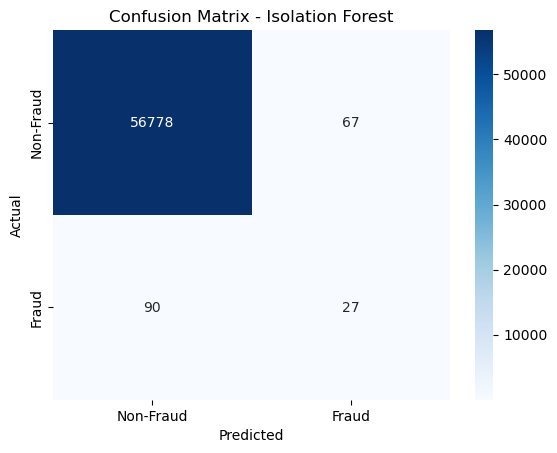

In [107]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Isolation Forest')
plt.show()


Conclusion

The Isolation Forest model reached about 99.7% overall accuracy, but on a dataset this imbalanced (fraud is roughly 0.17% of all transactions) accuracy alone doesn't tell the full story — the confusion matrix and classification report give a much clearer picture of how well the model actually catches fraud versus flagging false alarms.

Fraudulent transactions also tend to differ from normal ones in transaction amount, which is part of what the model implicitly picks up on alongside the anonymized V1-V28 features.

Future work includes trying supervised approaches like Logistic Regression or XGBoost with class weighting or SMOTE to handle the imbalance directly, tuning the contamination parameter, and comparing against other anomaly detection methods like Local Outlier Factor or a One-Class SVM.
